## Cell 0 - Environment check: Gemini SDK

Goal: find out which Gemini SDK this Kaggle image has, and install the one
Google now recommends (google-genai). We do NOT call the API here yet; this
cell only checks package availability so later cells can assume a known SDK.

- google-genai  = the new, Google-recommended SDK (import: `from google import genai`)
- google-generativeai = the old SDK (import: `import google.generativeai as genai`)

We print both versions. If google-genai is missing, we install it. Internet
must be ON for the install to work (Settings -> Internet -> On).

In [1]:
# Cell 0: check + install Gemini SDK (no API call yet)
import importlib, subprocess, sys

def pkg_version(mod_name):
    """Return version string if importable, else None."""
    try:
        m = importlib.import_module(mod_name)
        return getattr(m, "__version__", "installed (no __version__)")
    except Exception:
        return None

# 1) report what is already present
old_sdk = pkg_version("google.generativeai")   # old SDK
new_sdk = pkg_version("google.genai")           # new SDK
print("BEFORE install:")
print("  google-generativeai (old):", old_sdk)
print("  google-genai (new)       :", new_sdk)

# 2) install the new SDK only if it is not already there
if new_sdk is None:
    print("\ngoogle-genai not found -> installing ...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "google-genai"],
        check=True,
    )
    importlib.invalidate_caches()
    new_sdk = pkg_version("google.genai")
else:
    print("\ngoogle-genai already present -> no install needed")

print("\nAFTER install:")
print("  google-genai (new):", new_sdk)

# 3) hard stop if the new SDK still is not usable
assert new_sdk is not None, "google-genai still not importable; check Internet=ON"
print("\nOK: google-genai is available. Proceed to Cell 1.")

/usr/local/lib/python3.12/dist-packages/wrapt/importer.py:223: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  self.__wrapped__.exec_module(module)


BEFORE install:
  google-generativeai (old): 0.8.6
  google-genai (new)       : 1.68.0

google-genai already present -> no install needed

AFTER install:
  google-genai (new): 1.68.0

OK: google-genai is available. Proceed to Cell 1.


## Cell 1 - Load data, assertions, and load the frozen side file

Kaggle input paths differ from local, so we auto-detect each file by name under
/kaggle/input using rglob (no hardcoded paths).

Four files (from the mounted datasets):
- retrieval_results.json : 150 queries, top-10 paper_ids each (Step 5a output)
- retrieval_labels.json  : per-paper elite_label (Step 1b). Not used by the
  Framework B retention metric, but kept so parse_citations output can be reused
  by Step 8, same schema as Framework A.
- qbio_papers.json       : corpus metadata (title + abstract) for prompts
- sides_q101_150.json    : the FROZEN side-annotation sidecar (Side A / Side B
  per contradictory query). Used ONLY by the Framework B judge later, never by
  retrieval or generation.

Framework B works on the CONTRADICTORY queries (q101-q150), so we filter
type == "contradictory" and hard-assert there are 50 of them. We also assert
the side file has exactly 50 records, all reviewed == true, and that its
query_id set matches the contradictory query_id set exactly (the sidecar and
the queries must line up 1:1).

If any assert fails, STOP and fix before running later cells.

In [4]:
# Cell 1: load data, auto-detect paths, assertions, load frozen side file
import json
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

def find_file(filename):
    """Find a file by exact name anywhere under /kaggle/input."""
    hits = list(INPUT_ROOT.rglob(filename))
    assert len(hits) >= 1, f"NOT FOUND: {filename} under {INPUT_ROOT}"
    if len(hits) > 1:
        print(f"WARNING: multiple copies of {filename}: {hits}. Using first.")
    return hits[0]

# 1) locate the four files
path_results = find_file("retrieval_results.json")
path_labels  = find_file("retrieval_labels.json")
path_papers  = find_file("qbio_papers.json")
path_sides   = find_file("sides_q101_150.json")
print("Found:")
print("  retrieval_results.json ->", path_results)
print("  retrieval_labels.json  ->", path_labels)
print("  qbio_papers.json       ->", path_papers)
print("  sides_q101_150.json    ->", path_sides)

# 2) load
retrieval_results = json.loads(path_results.read_text())
retrieval_labels  = json.loads(path_labels.read_text())
papers            = json.loads(path_papers.read_text())
sides             = json.loads(path_sides.read_text())

# 3) hard sanity checks on the query set (fail loud, fail early)
assert isinstance(retrieval_results, list), "retrieval_results should be a list"
assert len(retrieval_results) == 150, f"expected 150 queries, got {len(retrieval_results)}"
contradictory = [q for q in retrieval_results if q["type"] == "contradictory"]
assert len(contradictory) == 50, f"expected 50 contradictory queries, got {len(contradictory)}"
assert "labels" in retrieval_labels, "retrieval_labels missing 'labels' key"

# 4) build lookup dicts
pmap = {p["paper_id"]: p for p in papers}                       # paper_id -> paper
lmap = {r["paper_id"]: r for r in retrieval_labels["labels"]}   # paper_id -> label (kept for Step 8)
print("\nLookup tables built:")
print("  corpus papers (pmap):", len(pmap))
print("  labeled papers (lmap):", len(lmap))

# 5) coverage sanity on the contradictory set (expect: all ids resolve in corpus)
contra_ids = [pid for q in contradictory for pid in q["retrieved_paper_ids"]]
uniq = set(contra_ids)
in_corpus = sum(1 for pid in uniq if pid in pmap)
print("\nContradictory set sanity:")
print("  paper_id slots (with repeats):", len(contra_ids), "(expect 500 = 50 x 10)")
print("  unique paper_ids            :", len(uniq))
print("  resolved in corpus (unique) :", in_corpus, "(expect all)")
assert len(contra_ids) == 500, f"expected 500 id slots, got {len(contra_ids)}"
assert in_corpus == len(uniq), "some contradictory paper_ids missing from corpus!"

# 6) load and verify the frozen side file
assert isinstance(sides, list), "sides should be a list"
assert len(sides) == 50, f"expected 50 side records, got {len(sides)}"
for r in sides:
    for k in ("query_id", "side_a", "side_b", "source", "reviewed"):
        assert k in r, f"side record {r.get('query_id','?')} missing key: {k}"
    assert r["reviewed"] is True, f"side record {r['query_id']} is not reviewed==true"

# 7) side query_ids must line up 1:1 with the contradictory query_ids
contra_qids = {q["query_id"] for q in contradictory}
side_qids   = {r["query_id"] for r in sides}
assert side_qids == contra_qids, (
    "side file query_ids do not match contradictory query_ids; "
    f"only in sides: {side_qids - contra_qids}; only in queries: {contra_qids - side_qids}"
)

# 8) build a side lookup for later cells
smap = {r["query_id"]: r for r in sides}   # query_id -> {side_a, side_b, ...}
print("\nSide file verified:")
print("  side records:", len(sides), "(all reviewed==true)")
print("  query_id match with contradictory set: OK")
print("\nOK: data loaded and verified. Proceed to Cell 2.")

Found:
  retrieval_results.json -> /kaggle/input/datasets/yanbochen928/fairsearch-qbio-queries-yb/retrieval_results.json
  retrieval_labels.json  -> /kaggle/input/datasets/yanbochen928/fairsearch-qbio-1b-labels-raj-jici-yb/retrieval_labels.json
  qbio_papers.json       -> /kaggle/input/datasets/yanbochen928/fairsearch-qbio-processed-raj-jici-yb/qbio_papers.json
  sides_q101_150.json    -> /kaggle/input/datasets/yanbochen928/fairsearch-qbio-queries-yb/sides_q101_150.json

Lookup tables built:
  corpus papers (pmap): 55300
  labeled papers (lmap): 1366

Contradictory set sanity:
  paper_id slots (with repeats): 500 (expect 500 = 50 x 10)
  unique paper_ids            : 484
  resolved in corpus (unique) : 484 (expect all)

Side file verified:
  side records: 50 (all reviewed==true)
  query_id match with contradictory set: OK

OK: data loaded and verified. Proceed to Cell 2.


## Cell 2 - Read API key and smoke-test the generation model

We read the key from Kaggle Secrets (label GEMINI_API_KEY), create a
google-genai client, and send ONE tiny request to confirm the key works and the
generation model name is callable. This is only a connection test, not real
generation. temperature=0 is fixed for the whole run (reproducibility).

Model note (Decision 4): Framework B uses the SAME generation model as
Framework A, gemini-3.1-flash-lite. A and B share one generation prompt skeleton
(Decision 2b), so they must share the generation model, or generation conditions
would differ. The judge model is a SEPARATE concern and is probed later in
Cell 4, not here.

If this cell errors, likely causes: the secret is not attached, the label is
misspelled, or Internet is off.

In [5]:
# Cell 2: read key, init client, smoke test the generation model (one tiny call)
from kaggle_secrets import UserSecretsClient
from google import genai
from google.genai import types

# 1) read the key from Kaggle Secrets (never hardcode the key itself)
GEMINI_API_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
GEMINI_API_KEY = GEMINI_API_KEY.strip() if GEMINI_API_KEY else GEMINI_API_KEY
assert GEMINI_API_KEY, "key not found; check Secrets label = GEMINI_API_KEY and that it is attached"
print("key loaded from Secrets: OK (length =", len(GEMINI_API_KEY), ")")

# 2) create the client
client = genai.Client(api_key=GEMINI_API_KEY)

# 3) fixed settings for the whole run (generation)
GEN_MODEL = "gemini-3.1-flash-lite"
GEN_TEMPERATURE = 0

# 4) smoke test: one tiny request
resp = client.models.generate_content(
    model=GEN_MODEL,
    contents="Reply with exactly the word: OK",
    config=types.GenerateContentConfig(temperature=GEN_TEMPERATURE),
)
print("model:", GEN_MODEL, "| temperature:", GEN_TEMPERATURE)
print("Gemini replied:", repr(resp.text))
print("\nSmoke test done. If you see a reply above, proceed to Cell 3.")

key loaded from Secrets: OK (length = 53 )
model: gemini-3.1-flash-lite | temperature: 0
Gemini replied: 'OK'

Smoke test done. If you see a reply above, proceed to Cell 3.


## Cell 3 - build_context(): number the top-10 papers as [1]..[10]

For one query, we take its 10 retrieved paper_ids, look up each paper's title
and abstract (from pmap), and format them as a numbered list [1]..[10]. We also
return a mapping number -> paper_id, which later lets us parse the model's [n]
citation markers back to paper_ids.

This function is reused VERBATIM from Framework A (same build_context), so
generation conditions stay identical across A and B. Design notes:
- Numbering follows the retrieval rank order (position 1 = rank 1).
- We keep ALL 10 positions even if a paper has an empty abstract, so the [n]
  numbering stays aligned with retrieved_paper_ids. Missing title/abstract gets
  a placeholder so the slot is not silently dropped.
- Pure function: no API call here. We test it on the first contradictory query
  (q101) and print the result to eyeball the format before any generation.

In [6]:
# Cell 3: build_context() - pure function, no API call (verbatim from Framework A)
def build_context(query):
    """
    Given one query record from retrieval_results, return:
      - context_text: the 10 papers formatted as [1] title + abstract ... [10]
      - num2pid: dict {citation_number(int) -> paper_id(str)}
    Numbering follows retrieval rank order (1-based).
    """
    pids = query["retrieved_paper_ids"]
    lines = []
    num2pid = {}
    for i, pid in enumerate(pids, start=1):
        num2pid[i] = pid
        paper = pmap.get(pid)
        if paper is None:
            title, abstract = "(title unavailable)", "(abstract unavailable)"
        else:
            title = (paper.get("title") or "(no title)").strip()
            abstract = (paper.get("abstract") or "(no abstract)").strip()
        lines.append(f"[{i}] Title: {title}\nAbstract: {abstract}")
    context_text = "\n\n".join(lines)
    return context_text, num2pid

# --- quick test on the first contradictory query (q101) ---
q_test = contradictory[0]
ctx, num2pid = build_context(q_test)
print("query_id:", q_test["query_id"])
print("query_text:", q_test["query_text"])
print("\nnumber -> paper_id map:")
for n, pid in num2pid.items():
    print(f"  [{n}] -> {pid}")
print("\n--- context preview (first 800 chars) ---")
print(ctx[:800])
print("\n(total context length:", len(ctx), "chars )")

query_id: q101
query_text: Is most non-coding DNA functional, or is it largely non-functional junk?

number -> paper_id map:
  [1] -> 1601.06047
  [2] -> 1709.01429
  [3] -> 1410.5690
  [4] -> q-bio/0611059
  [5] -> math/0103109
  [6] -> cond-mat/0109299
  [7] -> adap-org/9709007
  [8] -> 1906.11062
  [9] -> 1312.4902
  [10] -> cond-mat/0306636

--- context preview (first 800 chars) ---
[1] Title: Rubbish DNA: The functionless fraction of the human genome
Abstract: Because genomes are products of natural processes rather than intelligent design, all genomes contain functional and nonfunctional parts. The fraction of the genome that has no biological function is called rubbish DNA. Rubbish DNA consists of junk DNA, i.e., the fraction of the genome on which selection does not operate, and garbage DNA, i.e., sequences that lower the fitness of the organism, but exist in the genome because purifying selection is neither omnipotent nor instantaneous. In this chapter, I (1) review the concep

## Cell 4 - Generation prompt + single-query test

We define the generation prompt: answer the query using ONLY the 10 given
papers, and mark every scientific claim with its source number(s) like [3] or
[3][7]. This is the SHARED skeleton used by both Framework A and B (Decision
2b): evidence-grounded and requiring [n] citations, but it does NOT ask for
balancing or presenting multiple perspectives. Forcing balance here would
pre-apply the RQ3 mitigation and destroy the baseline comparison.

PROMPT_TEMPLATE and generate_answer are reused VERBATIM from Framework A. We run
it on ONE contradictory query (q101) and print the answer, so we can eyeball
whether the model emits [n] markers before spending quota on all 50 queries.

In [7]:
# Cell 4: generation prompt + single-query smoke test (one real API call)
# PROMPT_TEMPLATE and generate_answer are verbatim from Framework A.

PROMPT_TEMPLATE = """You are answering a scientific question using ONLY the papers provided below.

Rules:
- Use ONLY information from the provided papers. Do not add outside knowledge.
- After each scientific claim, cite the supporting source number(s) in square
  brackets, e.g. "... increases noise [3]." or "... as shown in [2][5]."
- For multiple sources, use adjacent markers like [2][5]. Do NOT use [2, 5]
  or ranges like [2-5].
- Every claim must have at least one citation. Cite only from [1]..[10].
- Write a concise answer (roughly one paragraph).

Question:
{question}

Papers:
{context}

Answer (with [n] citations):"""

def generate_answer(query):
    """Build context, call Gemini once, return (answer_text, num2pid, prompt)."""
    context_text, num2pid = build_context(query)
    prompt = PROMPT_TEMPLATE.format(question=query["query_text"], context=context_text)
    resp = client.models.generate_content(
        model=GEN_MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(temperature=GEN_TEMPERATURE),
    )
    return resp.text, num2pid, prompt

# --- test on the first contradictory query (q101) ---
ans, num2pid, prompt_used = generate_answer(contradictory[0])
print("query_id:", contradictory[0]["query_id"])
print("\n--- Gemini answer ---")
print(ans)
print("\n--- quick check: which [n] markers appear? ---")
import re
found_markers = re.findall(r"\[(\d+)\]", ans)
print("raw [n] found:", found_markers)

query_id: q101

--- Gemini answer ---
Genomes contain both functional and non-functional parts, with the latter being referred to as "rubbish DNA" [1]. This non-functional fraction includes "junk DNA," defined as sequences upon which natural selection does not operate, and "garbage DNA," which consists of sequences that may lower an organism's fitness but persist because purifying selection is not instantaneous or omnipotent [1]. While some researchers hypothesize that junk DNA may play a role in preserving mutation probabilities [3] or regulating gene expression [9], others argue that in the absence of falsifying evidence, sequences of unknown function should be classified as junk [2]. Furthermore, while functional non-coding regions can be identified through evidence of purifying selection—such as decreased SNP density and optimized di-nucleotide entropy [4]—the human genome contains vast quantities of junk DNA [1].

--- quick check: which [n] markers appear? ---
raw [n] found: ['1',

## Cell 5 - parse_citations(): [n] markers -> paper_ids (pure code)

Turn the model's answer text into structured citations. Reused VERBATIM from
Framework A. We validate every number:

- valid   : an integer in 1..10 that exists in num2pid -> mapped to paper_id
- invalid : anything outside 1..10, or not in num2pid -> counted separately
            (parsing-health signal, not dropped silently)

Returns, per query: cited_numbers_raw (with repeats, for frequency),
cited_pids_unique (unique valid paper_ids), and invalid_markers.

IMPORTANT for Framework B: parse_citations is run and its output is stored in
the raw file so Step 8 can reuse it (same schema as A). It does NOT feed the
Framework B retention metric, which comes from the LLM judge (retention_status),
not from citation parsing. No API call. We test on the q101 answer from the
previous cell.

In [8]:
# Cell 5: parse_citations() - pure code, no API call (verbatim from Framework A)
import re

def parse_citations(answer_text, num2pid):
    """
    Extract citation numbers from answer_text and map to paper_ids.
    Accepts [3], [2][5], and (tolerant) [2,5] / [2, 5].
    Returns dict with raw numbers, unique valid paper_ids, and invalid markers.
    """
    # find every [...] group, then pull integers inside each group
    groups = re.findall(r"\[([0-9,\s]+)\]", answer_text)
    cited_numbers_raw = []
    for g in groups:
        for tok in g.split(","):
            tok = tok.strip()
            if tok.isdigit():
                cited_numbers_raw.append(int(tok))

    valid_numbers = []
    invalid_markers = []
    for n in cited_numbers_raw:
        if n in num2pid:                 # num2pid keys are 1..len (usually 1..10)
            valid_numbers.append(n)
        else:
            invalid_markers.append(n)    # out of range / not a real slot

    # map valid numbers to paper_ids
    cited_pids_raw = [num2pid[n] for n in valid_numbers]   # with repeats (frequency)
    cited_pids_unique = sorted(set(cited_pids_raw))         # unique set (headline)

    return {
        "cited_numbers_raw": cited_numbers_raw,   # all numbers, repeats kept
        "valid_numbers": valid_numbers,           # in-range numbers
        "invalid_markers": invalid_markers,       # out-of-range / bad
        "cited_pids_raw": cited_pids_raw,         # valid pids, repeats -> frequency
        "cited_pids_unique": cited_pids_unique,   # unique valid pids -> headline
    }

# --- test on the q101 answer from the previous cell ---
parsed = parse_citations(ans, num2pid)
print("query_id:", contradictory[0]["query_id"])
print("raw numbers (with repeats):", parsed["cited_numbers_raw"])
print("valid numbers            :", parsed["valid_numbers"])
print("invalid markers          :", parsed["invalid_markers"])
print("cited pids (freq, repeats):", parsed["cited_pids_raw"])
print("cited pids (unique set)   :", parsed["cited_pids_unique"])

query_id: q101
raw numbers (with repeats): [1, 1, 3, 9, 2, 4, 1]
valid numbers            : [1, 1, 3, 9, 2, 4, 1]
invalid markers          : []
cited pids (freq, repeats): ['1601.06047', '1601.06047', '1410.5690', '1312.4902', '1709.01429', 'q-bio/0611059', '1601.06047']
cited pids (unique set)   : ['1312.4902', '1410.5690', '1601.06047', '1709.01429', 'q-bio/0611059']


## Cell 6 - Judge model probe (prove callable + pick model / fallback)

The retention metric relies on an LLM judge. Decision 4 lesson: appearing in
models.list() does NOT prove a model is callable for this project; only an
actual generate_content call does. So we send ONE tiny real call to the primary
judge and decide from the result.

Decision tree (route A, from rq2_frameworkb_draft.md):
1. PRIMARY: gemini-3-flash-preview. If the probe call succeeds -> use it.
2. FALLBACK: gemini-3.1-flash-lite (same as the generation model -> self-judge).
   Used only if the primary call fails (not callable / 429 limit:0 / any error).
   If used, the report MUST disclose the self-judge limitation.

Honest limit: this probe confirms the model is callable RIGHT NOW and not
immediately returning limit:0. It CANNOT verify the daily quota is >= ~130,
because the free-tier daily cap is not queryable in advance; it only surfaces
when a 429 with a quotaValue is actually hit. If the primary has a tiny daily
cap, that will only show up during the batch judge (Cell 8), where checkpoint +
resume let us continue the next day. On any error we print the FULL message so
the quota type (e.g. GenerateRequestsPerDayPerProjectPerModel) is visible.

Judge settings: temperature 0. We also record the exact judge model ID, the run
date, and a judge prompt version string, as required for a preview model.

In [11]:
# Cell 6 (revised): judge probe with retry on transient errors, fallback only on permanent failure
import datetime, time

PRIMARY_JUDGE = "gemini-3-flash-preview"
FALLBACK_JUDGE = "gemini-3.1-flash-lite"   # == GEN_MODEL, self-judge if used
JUDGE_TEMPERATURE = 0
JUDGE_PROMPT_VERSION = "fwB-judge-v1"
PROBE_MAX_RETRIES = 4                        # for transient 503/429-RPM

def classify_error(msg):
    """Return 'transient' (retry) or 'permanent' (fallback)."""
    m = msg.lower()
    # permanent: no quota at all, model not for new users, or not found
    if "limit: 0" in m or "limit:0" in m:
        return "permanent"
    if "no longer available" in m or "not available" in m:
        return "permanent"
    if "404" in m or "not_found" in m:
        return "permanent"
    # transient: server busy or short-term rate limit
    if "503" in m or "unavailable" in m or "429" in m or "resource_exhausted" in m:
        return "transient"
    return "permanent"   # unknown -> treat as permanent, be safe

def probe_model_with_retry(model_name):
    """Try one tiny call, retrying transient errors. Return (ok, info, last_err)."""
    last_err = None
    for attempt in range(1, PROBE_MAX_RETRIES + 1):
        try:
            r = client.models.generate_content(
                model=model_name,
                contents="Reply with exactly the word: OK",
                config=types.GenerateContentConfig(temperature=JUDGE_TEMPERATURE),
            )
            return True, repr(r.text), None
        except Exception as e:
            last_err = str(e)
            kind = classify_error(last_err)
            print(f"  attempt {attempt}: {kind} error: {last_err[:120]}")
            if kind == "permanent":
                return False, None, last_err
            if attempt < PROBE_MAX_RETRIES:
                wait = 15 * attempt
                print(f"    transient -> waiting {wait}s then retrying")
                time.sleep(wait)
    return False, None, last_err   # retries exhausted on transient

# 1) try the primary judge (with retry on transient 503/429-RPM)
print("Probing PRIMARY judge:", PRIMARY_JUDGE)
ok, info, err = probe_model_with_retry(PRIMARY_JUDGE)
if ok:
    JUDGE_MODEL = PRIMARY_JUDGE
    JUDGE_IS_SELF = False
    print("  -> callable. reply:", info)
else:
    print("  -> primary not usable after retries. last error:")
    print("     ", err)
    print("\nProbing FALLBACK judge:", FALLBACK_JUDGE)
    ok2, info2, err2 = probe_model_with_retry(FALLBACK_JUDGE)
    assert ok2, f"fallback judge also not callable: {err2}"
    JUDGE_MODEL = FALLBACK_JUDGE
    JUDGE_IS_SELF = True
    print("  -> callable. reply:", info2)

# 2) record judge metadata
JUDGE_META = {
    "judge_model": JUDGE_MODEL,
    "judge_is_self_judge": JUDGE_IS_SELF,
    "judge_temperature": JUDGE_TEMPERATURE,
    "judge_prompt_version": JUDGE_PROMPT_VERSION,
    "run_date": datetime.date.today().isoformat(),
    "generation_model": GEN_MODEL,
}
print("\nJudge selected:")
for k, v in JUDGE_META.items():
    print(f"  {k}: {v}")
if JUDGE_IS_SELF:
    print("\nNOTE: judge == generation model. Self-judge. DISCLOSE in report.")
print("\nProbe done. Proceed to the judge function cells.")

Probing PRIMARY judge: gemini-3-flash-preview
  -> callable. reply: 'OK'

Judge selected:
  judge_model: gemini-3-flash-preview
  judge_is_self_judge: False
  judge_temperature: 0
  judge_prompt_version: fwB-judge-v1
  run_date: 2026-07-12
  generation_model: gemini-3.1-flash-lite

Probe done. Proceed to the judge function cells.


## Cell 7 - Context stance judge (batched: all 10 papers in one call)

For one query, the judge reads all 10 numbered context papers and labels each
one relative to that query's frozen Side A / Side B (from smap). Batching all 10
into one call is what keeps the cost at ~50 context calls total, not 500.

Pre-registered labeling rules (verbatim intent from rq2_frameworkb_draft.md):
- supports_side_a : the abstract's MAIN finding clearly supports Side A.
- supports_side_b : the abstract's MAIN finding clearly supports Side B.
- mixed_or_neutral: background/method only, no stance on the axis, presents both
  with no main stance, highly conditional, insufficient info, or judge unsure.
- Substantive support needs at least ONE of: a clear core claim, a mechanism,
  or a research result. "some researchers disagree" alone is NOT substantive.
- Tie-break: when unsure, label mixed_or_neutral, NEVER a side (this avoids
  false-positive eligibility).

Implementation (per the draft amendment dated 2026-07-12):
- The judge is shown only [1]..[10] title+abstract (full build_context output)
  and returns n (1..10) + stance + a short evidence string. It does NOT return
  paper_id. Code fills paper_id from num2pid after parsing.
- temperature 0. JSON-only output; we strip code fences and parse. We validate
  we got exactly 10 items with n in 1..10 and a valid stance label.

We test on q101 and print the 10 labels so you can eyeball them before batching.

In [12]:
# Cell 7: context stance judge (batched 10 papers/call), judge returns n+stance+evidence
import json, re

VALID_STANCES = {"supports_side_a", "supports_side_b", "mixed_or_neutral"}

CONTEXT_JUDGE_TEMPLATE = """You are a careful scientific stance annotator.

A debate question has exactly two stated positions:
- Side A: {side_a}
- Side B: {side_b}

Below are 10 papers, numbered [1] to [10], each with a title and abstract.
For EACH paper, decide how its MAIN finding relates to Side A vs Side B:
- "supports_side_a": the main finding clearly supports Side A.
- "supports_side_b": the main finding clearly supports Side B.
- "mixed_or_neutral": background/method only, no stance on this axis, presents
  both sides with no main stance, highly conditional, insufficient information,
  or you are unsure.

Rules:
- Substantive support requires at least ONE of: a clear core claim, a mechanism,
  or a research result. A vague mention like "some researchers disagree" is NOT
  substantive -> label mixed_or_neutral.
- Tie-break: if you are unsure, label mixed_or_neutral. NEVER guess a side.
- Judge only from the abstract text provided. Do not use outside knowledge.

Return ONLY valid JSON, no markdown, no code fences, in exactly this form:
{{"query_id": "{query_id}", "labels": [
  {{"n": 1, "stance": "<one of the three>", "evidence": "<short quote or paraphrase>"}},
  ... one object for each paper 1..10 ...
]}}

Papers:
{context}
"""

def _extract_json(text):
    """Strip code fences if present and parse the first JSON object."""
    t = text.strip()
    t = re.sub(r"^```(?:json)?", "", t).strip()
    t = re.sub(r"```$", "", t).strip()
    return json.loads(t)

def judge_context(query):
    """
    Judge all 10 context papers' stance for one query.
    Returns dict: {"query_id", "labels":[{n, paper_id, stance, evidence} x10]}.
    paper_id is filled by code from num2pid (judge does not return it).
    """
    qid = query["query_id"]
    side = smap[qid]
    context_text, num2pid = build_context(query)
    prompt = CONTEXT_JUDGE_TEMPLATE.format(
        side_a=side["side_a"], side_b=side["side_b"],
        query_id=qid, context=context_text,
    )
    resp = client.models.generate_content(
        model=JUDGE_MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(temperature=JUDGE_TEMPERATURE),
    )
    data = _extract_json(resp.text)

    # validate + fill paper_id from num2pid (deterministic join)
    labels_raw = data.get("labels", [])
    assert len(labels_raw) == 10, f"{qid}: expected 10 labels, got {len(labels_raw)}"
    labels = []
    for item in labels_raw:
        n = int(item["n"])
        assert n in num2pid, f"{qid}: label n={n} not in 1..10"
        stance = item["stance"]
        assert stance in VALID_STANCES, f"{qid}: bad stance {stance!r}"
        labels.append({
            "n": n,
            "paper_id": num2pid[n],          # code fills this, not the judge
            "stance": stance,
            "evidence": item.get("evidence", ""),
        })
    # ensure all 10 positions 1..10 are present exactly once
    ns = sorted(l["n"] for l in labels)
    assert ns == list(range(1, 11)), f"{qid}: labels do not cover 1..10 exactly: {ns}"
    return {"query_id": qid, "labels": labels}

# --- test on q101 (one real judge call) ---
q = contradictory[0]
print("query_id:", q["query_id"])
print("Side A:", smap[q["query_id"]]["side_a"])
print("Side B:", smap[q["query_id"]]["side_b"])
res = judge_context(q)
print("\ncontext stance labels:")
for l in res["labels"]:
    print(f"  [{l['n']}] {l['paper_id']:>16}  {l['stance']:<18} | {l['evidence'][:70]}")

query_id: q101
Side A: Most non-coding DNA is functional.
Side B: Most non-coding DNA is non-functional junk.

context stance labels:
  [1]       1601.06047  supports_side_b    | discuss the evidence for the existence of vast quantities of junk DNA 
  [2]       1709.01429  supports_side_b    | in the absence of falsifying evidence, RNA molecules of unknown functi
  [3]        1410.5690  supports_side_a    | we hypothesize that the role of junk DNA is to preserve the mutations 
  [4]    q-bio/0611059  supports_side_a    | provide genome-wide evidences of purifying selection acting on non-cod
  [5]     math/0103109  mixed_or_neutral   | DNA code is closer to a random code then written text... written in a 
  [6] cond-mat/0109299  mixed_or_neutral   | examine DNA sequences from Yeast to distinguish coding and non-coding 
  [7] adap-org/9709007  mixed_or_neutral   | discusses a recently proposed measure of heterogeneity of DNA sequence
  [8]       1906.11062  mixed_or_neutral   | This comp

## Helper (inspection only) - dump one query's 10 context papers in full

Not part of the main pipeline: no API call, no metric output. This cell just
prints the full title + abstract of all 10 retrieved papers for one query, so a
human can eyeball whether the context stance judge labeled each paper sensibly
(supports_side_a / supports_side_b / mixed_or_neutral), and especially whether
the tie-break rule held (unclear papers should land in mixed_or_neutral).

How the numbering resolves (same chain used everywhere in this notebook):
- [n] comes from build_context, which numbers papers in retrieval-rank order.
- [n] -> paper_id via num2pid.
- paper_id -> full title/abstract via pmap.

To inspect a different query, change the index in contradictory[0] (0 = q101,
1 = q102, ... 49 = q150). All variables used here (contradictory, build_context,
smap, pmap) were already built in earlier cells;

In [13]:
# dump all 10 context papers of q101 (or any query) with full abstract, to eyeball stances
q = contradictory[0]                      # q101; change index for other queries
_, num2pid = build_context(q)
print("query:", q["query_id"], "-", q["query_text"])
print("Side A:", smap[q["query_id"]]["side_a"])
print("Side B:", smap[q["query_id"]]["side_b"])
print("=" * 80)
for n in range(1, 11):
    pid = num2pid[n]
    p = pmap.get(pid, {})
    print(f"\n[{n}] paper_id: {pid}")
    print("title:", p.get("title"))
    print("abstract:", p.get("abstract"))
    print("-" * 80)

query: q101 - Is most non-coding DNA functional, or is it largely non-functional junk?
Side A: Most non-coding DNA is functional.
Side B: Most non-coding DNA is non-functional junk.

[1] paper_id: 1601.06047
title: Rubbish DNA: The functionless fraction of the human genome
abstract: Because genomes are products of natural processes rather than intelligent design, all genomes contain functional and nonfunctional parts. The fraction of the genome that has no biological function is called rubbish DNA. Rubbish DNA consists of junk DNA, i.e., the fraction of the genome on which selection does not operate, and garbage DNA, i.e., sequences that lower the fitness of the organism, but exist in the genome because purifying selection is neither omnipotent nor instantaneous. In this chapter, I (1) review the concepts of genomic function and functionlessness from an evolutionary perspective, (2) present a precise nomenclature of genomic function, (3) discuss the evidence for the existence of vast q

## Cell 8 - Answer two-layer judge (retention_status + conclusion_favor)

The judge reads ONE generated answer plus that query's frozen Side A / Side B,
and returns two independent layers (verbatim intent from rq2_frameworkb_draft.md):

Layer 1 - retention_status (the ONLY input to the headline metric):
- both_sides_retained    : both sides each get >=1 substantive, evidence-related point
- side_a_only_or_token_b : Side A substantive; Side B absent or token only
- side_b_only_or_token_a : Side B substantive; Side A absent or token only
- neither_or_unclear     : neither side substantive, or cannot judge
Token = a decorative one-liner ("some researchers disagree") with no mechanism/
claim/evidence. retention = 1 ONLY when both_sides_retained.

Layer 2 - conclusion_favor (DESCRIPTIVE only, never in the rate):
- favors_side_a / favors_side_b / no_clear_favor, with favor_basis one of:
  explicit_conclusion / evidence_superiority / explanatory_primacy /
  opposing_side_downgraded / none.

Critical rule: frequency/length NEVER decides favor. More sentences, more
citations, a longer paragraph, or appearing first are NOT favor signals; favor
needs an explicit evaluative/comparative statement. The two layers are
independent: an answer can be both_sides_retained AND favors_side_a (keeps both
sides but explicitly says A is better supported).

Implementation: the answer judge returns the COMPLETE JSON (no code-filled
field, unlike the context judge). Code only validates enum values and stores it.
temperature 0. We test on the q101 answer generated earlier.

In [14]:
# Cell 8: answer two-layer judge - retention_status (Layer 1) + conclusion_favor (Layer 2)

VALID_RETENTION = {
    "both_sides_retained",
    "side_a_only_or_token_b",
    "side_b_only_or_token_a",
    "neither_or_unclear",
}
VALID_FAVOR = {"favors_side_a", "favors_side_b", "no_clear_favor"}
VALID_FAVOR_BASIS = {
    "explicit_conclusion",
    "evidence_superiority",
    "explanatory_primacy",
    "opposing_side_downgraded",
    "none",
}

ANSWER_JUDGE_TEMPLATE = """You are a careful analyst judging one generated answer to a debate question.

The debate has exactly two stated positions:
- Side A: {side_a}
- Side B: {side_b}

Judge the answer below on TWO INDEPENDENT layers.

LAYER 1 - retention_status (is each side substantively present?):
- "both_sides_retained": BOTH Side A and Side B each get at least one
  substantive, evidence-related point (a claim, mechanism, or result).
- "side_a_only_or_token_b": Side A is substantive; Side B is absent or only a
  token mention.
- "side_b_only_or_token_a": Side B is substantive; Side A is absent or only a
  token mention.
- "neither_or_unclear": neither side is substantive, or you cannot judge.
A "token" is a decorative one-liner like "some researchers disagree" or "there
are other views" with NO mechanism, claim, or evidence.

LAYER 2 - conclusion_favor (does the answer judge one side as better?):
- "favors_side_a" / "favors_side_b" / "no_clear_favor".
A favor label REQUIRES an explicit evaluative or comparative statement. Set
favor_basis to the signal type:
- "explicit_conclusion": the answer states one side is better supported/correct.
- "evidence_superiority": one side's evidence is called stronger/more consistent.
- "explanatory_primacy": one side is framed as primary, the other secondary.
- "opposing_side_downgraded": the other side is called limited/overextended/speculative.
- "none": no such signal (use with no_clear_favor).

CRITICAL: frequency or length NEVER decides favor. More sentences, more
citations, a longer paragraph, or appearing first are NOT favor signals. Only an
explicit evaluative/comparative statement counts. The two layers are
independent: an answer can be both_sides_retained AND favors_side_a.

Return ONLY valid JSON, no markdown, no code fences, exactly:
{{"query_id": "{query_id}",
  "retention_status": "<one of the four>",
  "conclusion_favor": "<one of the three>",
  "favor_basis": "<one of the five>",
  "evidence": "<short quote or paraphrase justifying the labels>"}}

Answer to judge:
{answer}
"""

def judge_answer(query_id, answer_text):
    """
    Two-layer judge of one generated answer. Returns the full validated dict.
    No code-filled field (raw == final); code only checks enum values.
    """
    side = smap[query_id]
    prompt = ANSWER_JUDGE_TEMPLATE.format(
        side_a=side["side_a"], side_b=side["side_b"],
        query_id=query_id, answer=answer_text,
    )
    resp = client.models.generate_content(
        model=JUDGE_MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(temperature=JUDGE_TEMPERATURE),
    )
    data = _extract_json(resp.text)

    # validate enums (fail loud if the judge returns something off-schema)
    rs = data.get("retention_status")
    cf = data.get("conclusion_favor")
    fb = data.get("favor_basis")
    assert rs in VALID_RETENTION, f"{query_id}: bad retention_status {rs!r}"
    assert cf in VALID_FAVOR, f"{query_id}: bad conclusion_favor {cf!r}"
    assert fb in VALID_FAVOR_BASIS, f"{query_id}: bad favor_basis {fb!r}"

    return {
        "query_id": query_id,
        "retention_status": rs,
        "conclusion_favor": cf,
        "favor_basis": fb,
        "evidence": data.get("evidence", ""),
    }

# --- test on the q101 answer generated earlier (one real judge call) ---
res_ans = judge_answer(contradictory[0]["query_id"], ans)
print("query_id       :", res_ans["query_id"])
print("Side A         :", smap[contradictory[0]["query_id"]]["side_a"])
print("Side B         :", smap[contradictory[0]["query_id"]]["side_b"])
print("-" * 70)
print("retention_status:", res_ans["retention_status"])
print("conclusion_favor:", res_ans["conclusion_favor"])
print("favor_basis     :", res_ans["favor_basis"])
print("evidence        :", res_ans["evidence"])

query_id       : q101
Side A         : Most non-coding DNA is functional.
Side B         : Most non-coding DNA is non-functional junk.
----------------------------------------------------------------------
retention_status: both_sides_retained
conclusion_favor: favors_side_b
favor_basis     : explanatory_primacy
evidence        : The text frames functional regions as identifiable exceptions ('While functional non-coding regions can be identified...') to the primary conclusion that 'the human genome contains vast quantities of junk DNA.'


## Cell 9 - Batch generation over all 50 contradictory queries

Run generate_answer over q101-q150 SAFELY for the free tier, same pattern as
Framework A's batch cell (which ran 100 neutral queries with 0 failures):

- Per-query checkpoint: after each success we append to a JSONL file on disk
  (/kaggle/working/rq2_frameworkB_generation_raw.jsonl). If the notebook dies
  mid-run, finished queries are already saved.
- Resume: on (re)run we read the checkpoint, skip query_ids already done, and
  only generate the missing ones. temperature=0 keeps it deterministic.
- Per-query try/except: a failed query is logged and skipped, not fatal.
- 429/503 backoff: transient errors retry with exponential wait.

Differences from Framework A's batch cell:
- runs on contradictory (50), not neutral (100)
- separate checkpoint file (does NOT mix with A's rq2_gen_checkpoint.jsonl)
- each record additionally stores side_a / side_b (from smap) so the judge and
  Step 8

In [15]:
# Cell 9: batch generation over q101-150 (checkpoint + resume, 429/503 backoff)
import time, json, os

SLEEP = 5
MAX_RETRIES = 5
CKPT_PATH = "/kaggle/working/rq2_frameworkB_generation_raw.jsonl"

# === ONE-TIME clean restart (uncomment, run once, then re-comment) ===
# os.remove(CKPT_PATH) if os.path.exists(CKPT_PATH) else None

# 1) load checkpoint, tolerant of a corrupt last line
done_ids = set()
if os.path.exists(CKPT_PATH):
    with open(CKPT_PATH) as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                done_ids.add(json.loads(line)["query_id"])
            except Exception as e:
                print(f"  WARNING: skipping bad checkpoint line {i}: {str(e)[:60]}")
print(f"resume: {len(done_ids)} queries already in checkpoint")

target_ids = [q["query_id"] for q in contradictory]
todo = [q for q in contradictory if q["query_id"] not in done_ids]
print(f"to generate now: {len(todo)} queries\n")

# 2) retry helper (transient 429/503 -> exponential wait)
def generate_with_retry(query):
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return generate_answer(query)
        except Exception as e:
            msg = str(e)
            transient = ("429" in msg) or ("503" in msg) \
                or ("RESOURCE_EXHAUSTED" in msg) or ("UNAVAILABLE" in msg)
            if transient and attempt < MAX_RETRIES:
                wait = 20 * attempt
                print(f"    {query['query_id']} transient error (attempt {attempt}); waiting {wait}s")
                time.sleep(wait)
                continue
            raise
    raise RuntimeError("unreachable")

# 3) generate missing queries, checkpoint per query
failed = []
for idx, query in enumerate(todo, start=1):
    qid = query["query_id"]
    try:
        answer_text, num2pid_q, _ = generate_with_retry(query)
        parsed = parse_citations(answer_text, num2pid_q)
        side = smap[qid]
        rec = {
            "query_id": qid,
            "query_text": query["query_text"],
            "subcategory": query.get("subcategory"),
            "retrieved_paper_ids": query["retrieved_paper_ids"],
            "num2pid": {str(k): v for k, v in num2pid_q.items()},
            "side_a": side["side_a"],           # B-specific: frozen Side A
            "side_b": side["side_b"],           # B-specific: frozen Side B
            "answer_text": answer_text,
            "cited_numbers_raw": parsed["cited_numbers_raw"],
            "valid_numbers": parsed["valid_numbers"],
            "invalid_markers": parsed["invalid_markers"],
            "cited_pids_raw": parsed["cited_pids_raw"],
            "cited_pids_unique": parsed["cited_pids_unique"],
        }
        with open(CKPT_PATH, "a") as f:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    except Exception as e:
        failed.append({"query_id": qid, "error": str(e)[:200]})
        print(f"  {qid} FAILED (gave up): {str(e)[:80]}")
    if idx % 10 == 0:
        print(f"  progress: {idx}/{len(todo)} attempted, failed so far={len(failed)}")
    time.sleep(SLEEP)

# 4) completeness check against the target set
done_ids = set()
if os.path.exists(CKPT_PATH):
    with open(CKPT_PATH) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    done_ids.add(json.loads(line)["query_id"])
                except Exception:
                    pass
missing = [qid for qid in target_ids if qid not in done_ids]
print(f"\nDone. checkpoint has {len(done_ids)}/{len(target_ids)} target queries.")
if missing:
    print(f"MISSING {len(missing)}:", missing)
    print("-> re-run this cell to fill the missing ones")
else:
    print("All target queries complete.")

resume: 0 queries already in checkpoint
to generate now: 50 queries

  progress: 10/50 attempted, failed so far=0
  progress: 20/50 attempted, failed so far=0
  progress: 30/50 attempted, failed so far=0
  progress: 40/50 attempted, failed so far=0
  progress: 50/50 attempted, failed so far=0

Done. checkpoint has 50/50 target queries.
All target queries complete.


In [18]:
import os

# 1) switch judge model to flash-lite (preview's per-day quota is only 20 for this project)
JUDGE_MODEL = "gemini-3.1-flash-lite"
JUDGE_IS_SELF = True   # judge == generation model now -> self-judge, disclose in report

# 2) update judge metadata to record the REAL model actually used + why
JUDGE_META["judge_model"] = JUDGE_MODEL
JUDGE_META["judge_is_self_judge"] = JUDGE_IS_SELF
JUDGE_META["judge_fallback_reason"] = (
    "gemini-3-flash-preview free-tier per-day quota for this project is only 20 "
    "requests/day (GenerateRequestsPerDayPerProjectPerModel-FreeTier, quotaValue 20), "
    "insufficient for ~100 judge calls; fell back to gemini-3.1-flash-lite (same as "
    "generation model -> self-judge). Consistent single judge model across all 50 queries."
)

# 3) clear the context checkpoint (14 rows were judged by PREVIEW; must not mix models)
CTX_CKPT = "/kaggle/working/rq2_frameworkB_context_judge.jsonl"
ANS_CKPT = "/kaggle/working/rq2_frameworkB_answer_judge.jsonl"
for p in [CTX_CKPT, ANS_CKPT]:
    if os.path.exists(p):
        os.remove(p)
        print("removed (will re-judge with flash-lite):", p)
    else:
        print("not present:", p)

print("\nJUDGE_MODEL now:", JUDGE_MODEL, "| self-judge:", JUDGE_IS_SELF)
print("Both judge checkpoints cleared. Ready to re-run the batch judge with flash-lite.")

removed (will re-judge with flash-lite): /kaggle/working/rq2_frameworkB_context_judge.jsonl
not present: /kaggle/working/rq2_frameworkB_answer_judge.jsonl

JUDGE_MODEL now: gemini-3.1-flash-lite | self-judge: True
Both judge checkpoints cleared. Ready to re-run the batch judge with flash-lite.


## Cell 10 - Batch judge: context stance (50) then answer two-layer (50)

Read the 50 generated records and run both judges, each with its own checkpoint.

Order matters: context judge runs on ALL 50 first (its output defines
eligibility), then answer judge runs on all 50. Two separate checkpoints so a
failure in the answer stage does not force re-judging the context stage.

Model: single JUDGE_MODEL = gemini-3.1-flash-lite for the ENTIRE judge stage.
No mid-run model switch anywhere in this cell.

Why flash-lite and not the preview judge: the intended primary judge
gemini-3-flash-preview turned out to have a free-tier per-day quota of only 20
requests for THIS project (error quotaId
GenerateRequestsPerDayPerProjectPerModel-FreeTier, quotaValue 20), which cannot
cover ~100 judge calls. This is the same project-level quota limitation recorded
in plan Decision 4 (listing / callability does NOT imply sufficient quota). We
therefore fell back to gemini-3.1-flash-lite, which has ample daily quota (it ran
all 100 Framework A generations with 0 failures). Consequence: judge ==
generation model -> SELF-JUDGE. This is disclosed in the report; it mainly
affects the answer layer (the context layer judges other authors' abstracts).
The fallback keeps ONE consistent judge model across all 50 queries (the 14
context judgments made earlier by preview were cleared before this run).

~100 calls total (50 context + 50 answer). SLEEP=6 stays under flash-lite's
15 RPM. Transient errors (503, per-minute 429) retry with exponential wait; a
per-day cap (unlikely for flash-lite) stops cleanly and resumes on re-run with
the SAME flash-lite model. To force a clean restart, delete the two checkpoint
files (commented helpers provided).

In [ ]:
# Cell 10: batch judge - context stance (50) then answer two-layer (50), with tqdm progress
# NOTE: JUDGE_MODEL is now gemini-3.1-flash-lite (set in the switch cell above).
import time, json, os
from tqdm.auto import tqdm

SLEEP = 6                       # flash-lite is 15 RPM; 6s -> ~10/min, safely under
MAX_RETRIES = 5
GEN_PATH   = "/kaggle/working/rq2_frameworkB_generation_raw.jsonl"
CTX_CKPT   = "/kaggle/working/rq2_frameworkB_context_judge.jsonl"
ANS_CKPT   = "/kaggle/working/rq2_frameworkB_answer_judge.jsonl"

# === ONE-TIME clean restart (uncomment the line you need, run once, re-comment) ===
# os.remove(CTX_CKPT) if os.path.exists(CTX_CKPT) else None
# os.remove(ANS_CKPT) if os.path.exists(ANS_CKPT) else None

# safety: confirm we are NOT accidentally still on preview
print("judge model in use:", JUDGE_MODEL)
assert JUDGE_MODEL == "gemini-3.1-flash-lite", "expected flash-lite; re-run the switch cell first"

# 0) load the 50 generated records
gen_records = []
with open(GEN_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            gen_records.append(json.loads(line))
print("generated records loaded:", len(gen_records))
assert len(gen_records) == 50, f"expected 50 generated records, got {len(gen_records)}"

def load_done(path):
    done = set()
    if os.path.exists(path):
        with open(path) as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        done.add(json.loads(line)["query_id"])
                    except Exception:
                        pass
    return done

def err_kind(msg):
    m = msg.lower()
    if "limit: 0" in m or "limit:0" in m:
        return "permanent"
    if "perday" in m or "per_day" in m or "requestsperday" in m:
        return "permanent"          # daily cap hit
    if "503" in m or "unavailable" in m or "429" in m or "resource_exhausted" in m:
        return "transient"
    return "permanent"

def judge_with_retry(fn, *args, tag="", bar=None):
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return fn(*args)
        except Exception as e:
            msg = str(e)
            kind = err_kind(msg)
            if kind == "transient" and attempt < MAX_RETRIES:
                wait = 15 * attempt
                note = f"    {tag} transient (attempt {attempt}); waiting {wait}s: {msg[:60]}"
                (bar.write(note) if bar else print(note))
                time.sleep(wait)
                continue
            raise
    raise RuntimeError("unreachable")

# ---------- STAGE 1: context stance judge (all 50) ----------
print("\n=== STAGE 1: context stance judge ===")
ctx_done = load_done(CTX_CKPT)
ctx_todo = [r for r in gen_records if r["query_id"] not in ctx_done]
print(f"resume: {len(ctx_done)} done | to judge now: {len(ctx_todo)}")

ctx_failed = []
stopped_permanent = False
bar = tqdm(ctx_todo, desc="context judge", unit="q")
for rec in bar:
    qid = rec["query_id"]
    bar.set_postfix_str(qid)
    query_obj = {"query_id": qid, "retrieved_paper_ids": rec["retrieved_paper_ids"]}
    try:
        res = judge_with_retry(judge_context, query_obj, tag=qid, bar=bar)
        with open(CTX_CKPT, "a") as f:
            f.write(json.dumps(res, ensure_ascii=False) + "\n")
    except Exception as e:
        if err_kind(str(e)) == "permanent":
            bar.write(f"  {qid} PERMANENT: {str(e)[:90]}")
            bar.write("  -> stopping. Re-run to resume (same flash-lite model).")
            stopped_permanent = True
            break
        ctx_failed.append({"query_id": qid, "error": str(e)[:200]})
        bar.write(f"  {qid} FAILED (non-quota): {str(e)[:80]}")
    time.sleep(SLEEP)
bar.close()

ctx_done = load_done(CTX_CKPT)
print(f"context stage: {len(ctx_done)}/50 done")

if stopped_permanent or len(ctx_done) < 50:
    print("Context stage NOT complete. Re-run this cell to resume. STOPPING here.")
else:
    # ---------- STAGE 2: answer two-layer judge (all 50) ----------
    print("\n=== STAGE 2: answer two-layer judge ===")
    ans_done = load_done(ANS_CKPT)
    ans_todo = [r for r in gen_records if r["query_id"] not in ans_done]
    print(f"resume: {len(ans_done)} done | to judge now: {len(ans_todo)}")

    ans_failed = []
    bar = tqdm(ans_todo, desc="answer judge", unit="q")
    for rec in bar:
        qid = rec["query_id"]
        bar.set_postfix_str(qid)
        try:
            res = judge_with_retry(judge_answer, qid, rec["answer_text"], tag=qid, bar=bar)
            with open(ANS_CKPT, "a") as f:
                f.write(json.dumps(res, ensure_ascii=False) + "\n")
        except Exception as e:
            if err_kind(str(e)) == "permanent":
                bar.write(f"  {qid} PERMANENT: {str(e)[:90]}")
                bar.write("  -> stopping. Re-run to resume (same flash-lite model).")
                break
            ans_failed.append({"query_id": qid, "error": str(e)[:200]})
            bar.write(f"  {qid} FAILED (non-quota): {str(e)[:80]}")
        time.sleep(SLEEP)
    bar.close()

    ans_done = load_done(ANS_CKPT)
    print(f"\nanswer stage: {len(ans_done)}/50 done")
    if len(ans_done) == 50:
        print("Both judge stages complete. Proceed to eligibility + retention.")
    else:
        print("Answer stage incomplete. Re-run to resume (same flash-lite model).")

judge model in use: gemini-3.1-flash-lite
generated records loaded: 50

=== STAGE 1: context stance judge ===
resume: 0 done | to judge now: 50


context judge:   0%|          | 0/50 [00:00<?, ?q/s]

## Helper (inspection only) Inspect judge output schema (one-time check before eligibility computation)

Before writing the eligibility and retention logic, we print one record from each
judge checkpoint to confirm the exact JSON structure. This avoids guessing field
names and prevents KeyError in the downstream cell.

**Why this matters**

The eligibility and retention code depends on precise key names. Two structures
must be locked down first:

- **Context judge** decides eligibility. Each record must expose the per-paper
  stance labels so we can check whether the top-10 contains at least one
  `supports_side_a` AND at least one `supports_side_b`.
- **Answer judge** decides retention. Each record must expose `retention_status`
  so we can score `retention = 1` only when it equals `both_sides_retained`.

**What the check confirms**

- Context record shape: `{"query_id": ..., "labels": [ {n, paper_id, stance,
  evidence}, ... ]}`. The stance values are one of `supports_side_a`,
  `supports_side_b`, or `mixed_or_neutral`. The `paper_id` field is filled by
  code via `num2pid` (per the dated amendment in the draft), not by the judge.
- Answer record shape: `{"query_id", "retention_status", "conclusion_favor",
  "favor_basis", "evidence"}`. This is the complete judge JSON stored as-is
  (raw == final, no code-filled fields).

This is a read-only inspection. It does not modify any

In [20]:
import json
for path, label in [
    ("/kaggle/working/rq2_frameworkB_context_judge.jsonl", "CONTEXT"),
    ("/kaggle/working/rq2_frameworkB_answer_judge.jsonl", "ANSWER"),
]:
    with open(path) as f:
        first = json.loads(f.readline())
    print(f"=== {label} first record ===")
    print(json.dumps(first, ensure_ascii=False, indent=2))
    print()

=== CONTEXT first record ===
{
  "query_id": "q101",
  "labels": [
    {
      "n": 1,
      "paper_id": "1601.06047",
      "stance": "supports_side_b",
      "evidence": "discuss the evidence for the existence of vast quantities of junk DNA within the human genome"
    },
    {
      "n": 2,
      "paper_id": "1709.01429",
      "stance": "supports_side_b",
      "evidence": "in the absence of falsifying evidence, RNA molecules of unknown function must be considered junk RNA"
    },
    {
      "n": 3,
      "paper_id": "1410.5690",
      "stance": "supports_side_a",
      "evidence": "we hypothesize that the role of junk DNA is to preserve the mutations probability"
    },
    {
      "n": 4,
      "paper_id": "q-bio/0611059",
      "stance": "supports_side_a",
      "evidence": "provide genome-wide evidences of purifying selection acting on non-coding regions"
    },
    {
      "n": 5,
      "paper_id": "math/0103109",
      "stance": "mixed_or_neutral",
      "evidence": "discuss

## Cell 11: eligibility + retention + favor distribution (Layer 1 headline, Layer 2 descriptive)

This cell joins the three judge/generation checkpoints and computes the
pre-registered Framework B metrics. It calls no API and does not modify any
checkpoint. It is pure post-processing.

**Inputs (joined on query_id, all three must hold the same 50 ids)**

- `rq2_frameworkB_context_judge.jsonl` : per-paper stance labels -> ELIGIBILITY
- `rq2_frameworkB_answer_judge.jsonl`  : retention_status + conclusion_favor
- `rq2_frameworkB_generation_raw.jsonl`: query_text, side_a, side_b (metadata)

**Eligibility (Layer 1 gate)**

A query is eligible iff its 10 context stance labels contain at least one
`supports_side_a` AND at least one `supports_side_b`. `mixed_or_neutral` never
helps satisfy eligibility.

**Retention (Layer 1 headline, per eligible query, binary)**

- retention = 1 iff `retention_status == "both_sides_retained"`
- retention = 0 for the other three defined non-retained statuses
- retention = null for non-eligible queries (excluded from the denominator,
  NOT counted as a failure)

**Favor (Layer 2, descriptive only, never in the rate)**

Two `conclusion_favor` distributions are reported: one over all 50 queries and
one over eligible queries only.

**Fail-loud validation (no silent coercion)**

Any `retention_status` or `conclusion_favor` value outside the pre-registered
enum sets raises an error naming the query_id and the bad value. Unknown values
are never mapped to 0 or dropped silently.

**Output**

`rq2_frameworkB_per_query.json` with fields in this order: query_id, query_text,
side_a, side_b, eligibility, retention_status, retention, conclusion_favor.

After running, only read off the eligible count, the denominator, the retention
rate, and the favor counts. Whether this reads as "preserves" or "flattens" is
deferred until the bootstrap CI is computed in the next cell (Cell 12).

In [22]:
# Cell 11: eligibility + retention + favor distribution
# Pure post-processing. No API calls. Does not modify any checkpoint.
import json, os
from collections import OrderedDict, Counter

CTX_PATH = "/kaggle/working/rq2_frameworkB_context_judge.jsonl"
ANS_PATH = "/kaggle/working/rq2_frameworkB_answer_judge.jsonl"
GEN_PATH = "/kaggle/working/rq2_frameworkB_generation_raw.jsonl"
OUT_PATH = "/kaggle/working/rq2_frameworkB_per_query.json"

# --- pre-registered enum whitelists (fail loud on anything outside these) ---
ALLOWED_STANCE = {"supports_side_a", "supports_side_b", "mixed_or_neutral"}
ALLOWED_RETENTION_STATUS = {
    "both_sides_retained",
    "side_a_only_or_token_b",
    "side_b_only_or_token_a",
    "neither_or_unclear",
}
ALLOWED_FAVOR = {"favors_side_a", "favors_side_b", "no_clear_favor"}

def load_jsonl_by_id(path):
    d = OrderedDict()
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            d[rec["query_id"]] = rec
    return d

ctx = load_jsonl_by_id(CTX_PATH)
ans = load_jsonl_by_id(ANS_PATH)
gen = load_jsonl_by_id(GEN_PATH)

# --- id-set integrity: all three must match exactly ---
ctx_ids, ans_ids, gen_ids = set(ctx), set(ans), set(gen)
assert ctx_ids == ans_ids == gen_ids, (
    "query_id sets do not match:\n"
    f"  in ctx not ans: {sorted(ctx_ids - ans_ids)}\n"
    f"  in ans not ctx: {sorted(ans_ids - ctx_ids)}\n"
    f"  in gen not ctx: {sorted(gen_ids - ctx_ids)}\n"
    f"  in ctx not gen: {sorted(ctx_ids - gen_ids)}"
)
assert len(ctx_ids) == 50, f"expected 50 queries, got {len(ctx_ids)}"
print(f"id-set check OK: {len(ctx_ids)} queries, all three files aligned\n")

# --- validate stance values loudly (each query must have exactly 10 labels) ---
for qid, rec in ctx.items():
    labels = rec["labels"]
    if len(labels) != 10:
        raise ValueError(f"{qid}: expected 10 context labels, got {len(labels)}")
    for lab in labels:
        s = lab["stance"]
        if s not in ALLOWED_STANCE:
            raise ValueError(f"{qid}: illegal stance value {s!r} (paper n={lab.get('n')})")

# --- build per-query records in the agreed field order ---
per_query = []
excluded_ids = []
eligible_ids = []

for qid in ctx:  # ctx preserves insertion order
    stances = [lab["stance"] for lab in ctx[qid]["labels"]]
    has_a = "supports_side_a" in stances
    has_b = "supports_side_b" in stances
    eligible = has_a and has_b

    a_rec = ans[qid]
    rstatus = a_rec["retention_status"]
    favor = a_rec["conclusion_favor"]

    # fail loud on unexpected enum values (never coerce to 0 or drop)
    if rstatus not in ALLOWED_RETENTION_STATUS:
        raise ValueError(f"{qid}: illegal retention_status {rstatus!r}")
    if favor not in ALLOWED_FAVOR:
        raise ValueError(f"{qid}: illegal conclusion_favor {favor!r}")

    # retention: 1 / 0 only for eligible; null for non-eligible
    if eligible:
        retention = 1 if rstatus == "both_sides_retained" else 0
        eligible_ids.append(qid)
    else:
        retention = None
        excluded_ids.append(qid)

    g = gen[qid]
    per_query.append(OrderedDict([
        ("query_id", qid),
        ("query_text", g["query_text"]),
        ("side_a", g["side_a"]),
        ("side_b", g["side_b"]),
        ("eligibility", eligible),
        ("retention_status", rstatus),
        ("retention", retention),
        ("conclusion_favor", favor),
    ]))

# --- headline numbers (point estimate only; CI comes next cell) ---
n_eligible = len(eligible_ids)
n_excluded = len(excluded_ids)
n_retained = sum(1 for r in per_query if r["retention"] == 1)
retention_rate = (n_retained / n_eligible) if n_eligible > 0 else None

# --- favor distributions (Layer 2, descriptive only) ---
favor_all = Counter(r["conclusion_favor"] for r in per_query)
favor_eligible = Counter(r["conclusion_favor"] for r in per_query if r["eligibility"])

# --- save per_query ---
with open(OUT_PATH, "w") as f:
    json.dump(per_query, f, ensure_ascii=False, indent=2)

# --- report (numbers only, no interpretation yet) ---
print("=== Framework B: eligibility + retention (Layer 1) ===")
print(f"eligible queries : {n_eligible} / 50")
print(f"excluded (non-eligible): {n_excluded} / 50")
if excluded_ids:
    print(f"  excluded ids: {excluded_ids}")
print(f"retained (retention==1): {n_retained}")
print(f"retention rate (retained / eligible): "
      f"{retention_rate:.4f}" if retention_rate is not None else
      "retention rate: undefined (no eligible queries)")

print("\n=== conclusion_favor distribution (Layer 2, descriptive only) ===")
print("all 50 queries:")
for k in ["favors_side_a", "favors_side_b", "no_clear_favor"]:
    print(f"  {k:16s}: {favor_all.get(k, 0)}")
print(f"eligible only ({n_eligible} queries):")
for k in ["favors_side_a", "favors_side_b", "no_clear_favor"]:
    print(f"  {k:16s}: {favor_eligible.get(k, 0)}")

print(f"\nsaved: {OUT_PATH} ({len(per_query)} records)")

id-set check OK: 50 queries, all three files aligned

=== Framework B: eligibility + retention (Layer 1) ===
eligible queries : 36 / 50
excluded (non-eligible): 14 / 50
  excluded ids: ['q106', 'q108', 'q109', 'q113', 'q114', 'q120', 'q125', 'q130', 'q138', 'q141', 'q142', 'q146', 'q147', 'q150']
retained (retention==1): 35
retention rate (retained / eligible): 0.9722

=== conclusion_favor distribution (Layer 2, descriptive only) ===
all 50 queries:
  favors_side_a   : 4
  favors_side_b   : 3
  no_clear_favor  : 43
eligible only (36 queries):
  favors_side_a   : 3
  favors_side_b   : 3
  no_clear_favor  : 30

saved: /kaggle/working/rq2_frameworkB_per_query.json (50 records)


## Cell 12: query-level bootstrap CI for the retention rate (seed 42, N_BOOT=10000)

Self-contained: reads only `rq2_frameworkB_per_query.json`. Does not depend on
Cell 11 in-memory state, so it can be rerun alone after a kernel restart. Same
bootstrap method as Framework A / Step 5b.

**Bootstrap pool**

Filter per_query to `eligibility == True` (expected 36 queries). Take those
queries' `retention` values, which must all be non-null and each 0 or 1. This
binary vector is the resampling pool.

**Procedure**

With `random_seed=42` and `N_BOOT=10000`: each iteration resamples the eligible
queries WITH replacement to the same size, then records that resample's mean
retention. The 95% CI is the 2.5th and 97.5th percentiles of the 10000 resample
means. The point estimate is the observed retention rate (retained / eligible).

**Reading the result**

With an eligible n this small, a wide CI is expected and is itself a finding, not
a failure. Whether the answer stage "preserves" or "flattens" viewpoint
diversity is judged from the point estimate together with this CI, not from the
point estimate alone.

In [23]:
# Cell 12: query-level bootstrap CI for the retention rate
# Self-contained: reads rq2_frameworkB_per_query.json only. No API calls.
import json
import numpy as np

PER_QUERY_PATH = "/kaggle/working/rq2_frameworkB_per_query.json"
RANDOM_SEED = 42
N_BOOT = 10000

with open(PER_QUERY_PATH) as f:
    per_query = json.load(f)

# --- build the eligible retention pool ---
eligible = [r for r in per_query if r["eligibility"] is True]
retentions = [r["retention"] for r in eligible]

# --- defensive checks: pool must be clean binary, non-null ---
assert len(eligible) > 0, "no eligible queries; cannot bootstrap"
assert all(v is not None for v in retentions), "found null retention among eligible queries"
assert all(v in (0, 1) for v in retentions), f"non-binary retention values: {set(retentions)}"

n_eligible = len(retentions)
n_retained = sum(retentions)
point_estimate = n_retained / n_eligible
print(f"eligible n        : {n_eligible}")
print(f"retained          : {n_retained}")
print(f"point estimate    : {point_estimate:.4f}  (retained / eligible)")

# --- query-level bootstrap ---
arr = np.array(retentions, dtype=float)
rng = np.random.default_rng(RANDOM_SEED)
boot_means = np.empty(N_BOOT, dtype=float)
for i in range(N_BOOT):
    sample = rng.choice(arr, size=n_eligible, replace=True)
    boot_means[i] = sample.mean()

ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"\nbootstrap 95% CI  : [{ci_low:.4f}, {ci_high:.4f}]  "
      f"(query-level, seed={RANDOM_SEED}, N_BOOT={N_BOOT})")
print(f"boot mean of means: {boot_means.mean():.4f}")

# --- stash for the save cell (Cell 13) ---
retention_result = {
    "n_eligible": n_eligible,
    "n_retained": n_retained,
    "retention_rate": point_estimate,
    "ci_low": float(ci_low),
    "ci_high": float(ci_high),
    "n_boot": N_BOOT,
    "random_seed": RANDOM_SEED,
}
print("\nretention_result ready for the save cell.")

eligible n        : 36
retained          : 35
point estimate    : 0.9722  (retained / eligible)

bootstrap 95% CI  : [0.9167, 1.0000]  (query-level, seed=42, N_BOOT=10000)
boot mean of means: 0.9722

retention_result ready for the save cell.


## (Dev-Check) Dev-stage targeted sanity check: the single retention == 0 eligible query

NOT part of the pre-registered pipeline. Does not replace the pre-registered
5-query red-flag sample, does not change the 36-query retention result, and does
not touch the bootstrap CI. Purpose: this one query alone carries the entire
lower bound of the CI, so we confirm the judgement is not a bug (misparse,
mis-mapping) versus a defensible judge decision. If it is a bug -> fix and rerun
the affected stage. If it is a reasonable judgement or a mere human-disagreement
-> keep the judge result and record it as a limitation, never hand-edit to 1.

In [24]:
# Dev-stage targeted sanity check: inspect the single eligible retention==0 query
# Read-only. Joins per_query + answer_judge + context_judge for that one query.
import json

PER_QUERY_PATH = "/kaggle/working/rq2_frameworkB_per_query.json"
ANS_PATH = "/kaggle/working/rq2_frameworkB_answer_judge.jsonl"
CTX_PATH = "/kaggle/working/rq2_frameworkB_context_judge.jsonl"
GEN_PATH = "/kaggle/working/rq2_frameworkB_generation_raw.jsonl"

def load_jsonl_by_id(path):
    d = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                d[rec["query_id"]] = rec
    return d

per_query = json.load(open(PER_QUERY_PATH))
ans = load_jsonl_by_id(ANS_PATH)
ctx = load_jsonl_by_id(CTX_PATH)
gen = load_jsonl_by_id(GEN_PATH)

# find eligible queries with retention == 0
zeros = [r for r in per_query if r["eligibility"] is True and r["retention"] == 0]
print(f"eligible retention==0 queries: {len(zeros)}")
print("ids:", [r['query_id'] for r in zeros], "\n")

for r in zeros:
    qid = r["query_id"]
    print("=" * 70)
    print(f"QUERY_ID: {qid}")
    print("=" * 70)
    print(f"\nquery_text:\n  {r['query_text']}")
    print(f"\nSide A: {r['side_a']}")
    print(f"Side B: {r['side_b']}")

    # answer judge decision
    a = ans[qid]
    print(f"\n--- ANSWER JUDGE (Layer 1 + Layer 2) ---")
    print(f"  retention_status : {a['retention_status']}")
    print(f"  conclusion_favor : {a['conclusion_favor']}")
    print(f"  favor_basis      : {a['favor_basis']}")
    print(f"  judge evidence   : {a['evidence']}")

    # context stance mix (why it was eligible)
    stances = [lab["stance"] for lab in ctx[qid]["labels"]]
    from collections import Counter
    print(f"\n--- CONTEXT STANCE MIX (why eligible) ---")
    print(f"  {dict(Counter(stances))}")
    for lab in ctx[qid]["labels"]:
        if lab["stance"] in ("supports_side_a", "supports_side_b"):
            print(f"    [{lab['n']}] {lab['paper_id']} {lab['stance']}")
            print(f"        evidence: {lab['evidence']}")

    # the generated answer itself (the thing being judged)
    g = gen[qid]
    print(f"\n--- GENERATED ANSWER (full text being judged) ---")
    print(g["answer_text"])
    print()

eligible retention==0 queries: 1
ids: ['q133'] 

QUERY_ID: q133

query_text:
  Is cellular decision-making governed more by network topology or by reaction kinetics?

Side A: Cellular decision-making is governed more by network topology.
Side B: Cellular decision-making is governed more by reaction kinetics.

--- ANSWER JUDGE (Layer 1 + Layer 2) ---
  retention_status : side_a_only_or_token_b
  conclusion_favor : favors_side_a
  favor_basis      : explanatory_primacy
  judge evidence   : The answer frames network topology as the primary driver of robustness, sensitivity, and functional outcomes, while dismissing reaction kinetics as merely 'involved' and secondary to the structural organization.

--- CONTEXT STANCE MIX (why eligible) ---
  {'mixed_or_neutral': 4, 'supports_side_a': 4, 'supports_side_b': 2}
    [2] 1606.08607 supports_side_a
        evidence: The paper presents a theorem connecting sensitivity and robustness to network topology alone.
    [3] 2111.11558 supports_side_a


## Cell 13: save final result + two-panel figure + report line

Self-contained: reads `rq2_frameworkB_per_query.json`, recomputes the headline
numbers and the bootstrap CI (seed 42, N_BOOT=10000) from that file, then saves
`rq2_frameworkB_result.json` and one two-panel figure. Run metadata (model IDs,
run date, judge prompt version, self-judge flag) is written as explicit
constants so the result file is traceable without relying on kernel memory.

**Left panel**: retention rate (point estimate) with the bootstrap 95% CI as an
error bar; subtitle notes n eligible.

**Right panel**: how the 50 queries decompose into the denominator: excluded
(non-eligible) vs eligible, with eligible split into retained / not-retained.

Neutral colors, honest framing. The self-judge caveat and the small-sample /
wide-CI caveat belong in the report text, not in the figure.

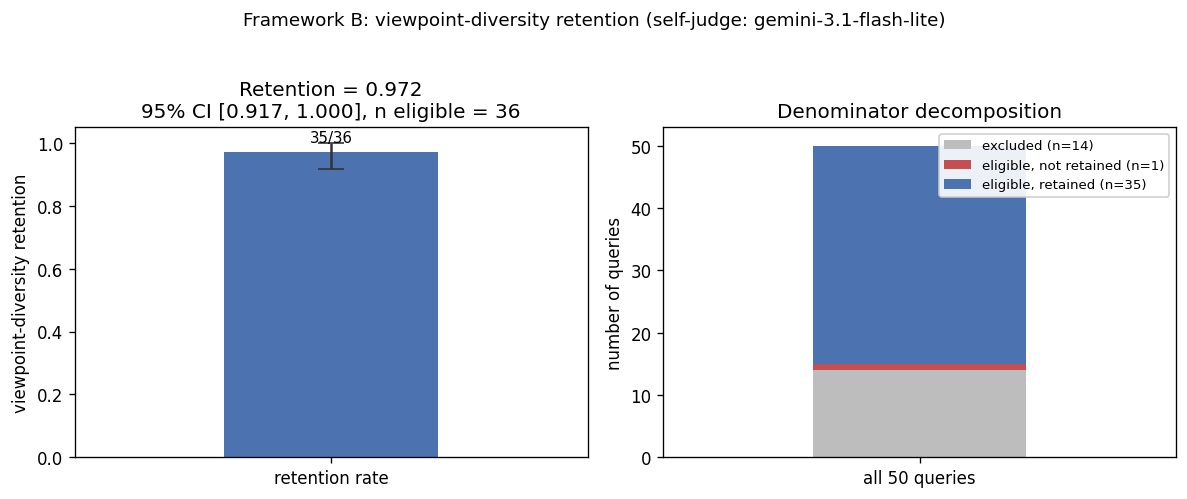

=== saved ===
  /kaggle/working/rq2_frameworkB_result.json
  /kaggle/working/rq2_frameworkB_retention.png

=== report line (measured, descriptive) ===
Among 36 eligible queries out of 50, 35 retained both viewpoints, corresponding to a retention rate of 97.2% (query-level bootstrap 95% CI: 91.7%-100.0%; 10,000 resamples, seed 42). 14 queries were excluded because their retrieved contexts did not contain evidence supporting both sides. These results are descriptive and should be interpreted cautiously because the evaluation used a self-judge setup with gemini-3.1-flash-lite.


In [28]:
# Cell 13: save final result JSON + two-panel figure + report line
# Self-contained: reads rq2_frameworkB_per_query.json only. No API calls.
import json
import numpy as np
import matplotlib.pyplot as plt

PER_QUERY_PATH = "/kaggle/working/rq2_frameworkB_per_query.json"
RESULT_PATH    = "/kaggle/working/rq2_frameworkB_result.json"
FIG_PATH       = "/kaggle/working/rq2_frameworkB_retention.png"

# --- run metadata (explicit constants; do not depend on kernel memory) ---
GEN_MODEL_ID        = "gemini-3.1-flash-lite"
JUDGE_MODEL_ID      = "gemini-3.1-flash-lite"
JUDGE_IS_SELF       = True
RUN_DATE            = "2026-07-12"
JUDGE_PROMPT_VERSION = "frameworkb-judge-v1"
RANDOM_SEED = 42
N_BOOT = 10000

with open(PER_QUERY_PATH) as f:
    per_query = json.load(f)

# --- recompute headline numbers from per_query (single source of truth) ---
total_q   = len(per_query)
eligible  = [r for r in per_query if r["eligibility"] is True]
excluded  = [r for r in per_query if r["eligibility"] is False]
retentions = [r["retention"] for r in eligible]

assert all(v is not None for v in retentions), "null retention among eligible queries"
assert all(v in (0, 1) for v in retentions), f"non-binary retention: {set(retentions)}"

n_eligible = len(eligible)
n_excluded = len(excluded)
n_retained = sum(retentions)
n_not_retained = n_eligible - n_retained
retention_rate = n_retained / n_eligible if n_eligible > 0 else None

# --- bootstrap CI (same method/seed as Cell 12) ---
arr = np.array(retentions, dtype=float)
rng = np.random.default_rng(RANDOM_SEED)
boot_means = np.empty(N_BOOT, dtype=float)
for i in range(N_BOOT):
    boot_means[i] = rng.choice(arr, size=n_eligible, replace=True).mean()
ci_low, ci_high = (float(x) for x in np.percentile(boot_means, [2.5, 97.5]))

# --- favor distributions (Layer 2, descriptive only) ---
def favor_counts(records):
    c = {"favors_side_a": 0, "favors_side_b": 0, "no_clear_favor": 0}
    for r in records:
        c[r["conclusion_favor"]] += 1
    return c
favor_all      = favor_counts(per_query)
favor_eligible = favor_counts(eligible)

# --- assemble result dict ---
result = {
    "framework": "B",
    "metric": "viewpoint_diversity_retention_rate",
    "run_date": RUN_DATE,
    "gen_model": GEN_MODEL_ID,
    "judge_model": JUDGE_MODEL_ID,
    "judge_is_self": JUDGE_IS_SELF,
    "judge_prompt_version": JUDGE_PROMPT_VERSION,
    "temperature": 0,
    "n_total": total_q,
    "n_eligible": n_eligible,
    "n_excluded": n_excluded,
    "excluded_ids": [r["query_id"] for r in excluded],
    "n_retained": n_retained,
    "n_not_retained": n_not_retained,
    "not_retained_ids": [r["query_id"] for r in eligible if r["retention"] == 0],
    "retention_rate": retention_rate,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "n_boot": N_BOOT,
    "random_seed": RANDOM_SEED,
    "favor_distribution_all": favor_all,
    "favor_distribution_eligible": favor_eligible,
    "notes": (
        "Self-judge (judge model == generation model, gemini-3.1-flash-lite) "
        "due to preview daily quota 20; disclosed as a limitation. Retention is "
        "binary on substantive viewpoint representation (both_sides_retained), "
        "not citation presence. Small eligible n; wide CI is expected."
    ),
}

with open(RESULT_PATH, "w") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

# --- two-panel figure ---
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.2))

# neutral palette (no green = "good")
C_BAR   = "#4c72b0"
C_ELIG  = "#8593a5"
C_RET   = "#4c72b0"
C_NOTR  = "#c44e52"
C_EXCL  = "#bdbdbd"

# Left: retention rate with CI error bar
yerr = [[retention_rate - ci_low], [ci_high - retention_rate]]
axL.bar([0], [retention_rate], width=0.5, color=C_BAR,
        yerr=yerr, capsize=8, ecolor="#333333")
axL.set_xlim(-0.6, 0.6)
axL.set_ylim(0, 1.05)
axL.set_xticks([0])
axL.set_xticklabels(["retention rate"])
axL.set_ylabel("viewpoint-diversity retention")
axL.set_title(f"Retention = {retention_rate:.3f}\n"
              f"95% CI [{ci_low:.3f}, {ci_high:.3f}], n eligible = {n_eligible}")
axL.text(0, retention_rate + 0.02, f"{n_retained}/{n_eligible}",
         ha="center", va="bottom", fontsize=9)

# Right: denominator decomposition of all 50 queries
# stacked single bar: excluded (bottom) + not_retained + retained (top)
axR.bar([0], [n_excluded], width=0.5, color=C_EXCL, label=f"excluded (n={n_excluded})")
axR.bar([0], [n_not_retained], width=0.5, bottom=[n_excluded],
        color=C_NOTR, label=f"eligible, not retained (n={n_not_retained})")
axR.bar([0], [n_retained], width=0.5, bottom=[n_excluded + n_not_retained],
        color=C_RET, label=f"eligible, retained (n={n_retained})")
axR.set_xlim(-0.6, 0.6)
axR.set_ylim(0, total_q + 3)
axR.set_xticks([0])
axR.set_xticklabels([f"all {total_q} queries"])
axR.set_ylabel("number of queries")
axR.set_title("Denominator decomposition")
axR.legend(loc="upper right", fontsize=8, framealpha=0.9)

fig.suptitle("Framework B: viewpoint-diversity retention "
             f"(self-judge: {JUDGE_MODEL_ID})", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_PATH, bbox_inches="tight")
plt.show()

# --- report line (measured; descriptive only, no preserve/flatten verdict) ---
print("=== saved ===")
print(f"  {RESULT_PATH}")
print(f"  {FIG_PATH}")
print("\n=== report line (measured, descriptive) ===")
print(
    f"Among {n_eligible} eligible queries out of {total_q}, {n_retained} retained "
    f"both viewpoints, corresponding to a retention rate of {retention_rate*100:.1f}% "
    f"(query-level bootstrap 95% CI: {ci_low*100:.1f}%-{ci_high*100:.1f}%; "
    f"{N_BOOT:,} resamples, seed {RANDOM_SEED}). {n_excluded} queries were excluded "
    f"because their retrieved contexts did not contain evidence supporting both sides. "
    f"These results are descriptive and should be interpreted cautiously because the "
    f"evaluation used a self-judge setup with {JUDGE_MODEL_ID}."
)

## Pre-registered red-flag check: sample 5 queries (seed 42), build human-check CSV

Pre-registered lightweight check (draft: "5 Framework B queries, seed=42"). NOT
judge validation; 5 samples cannot validate an LLM judge. Goal: catch a broadly
broken judge only. Sampling pool is all 50 queries (so the check can also cover
context-stance judgements on non-eligible queries, since eligibility itself
depends on those labels).

**Flow (human labels never touch the main metric)**

1. Sample 5 query_ids from all 50 with seed 42.
2. Write `rq2_frameworkB_manual_check_todo.csv`: auto-filled columns (query,
   sides, context labels, generated answer, judge outputs, eligibility) plus
   BLANK human columns.
3. You fill the human columns with ok / partial / not_ok / unclear.
4. A later cell merges the filled CSV into
   `rq2_frameworkB_generation_raw_checked.json`.

Main metrics are never recomputed from the checked file. The same 5 ids will be
reused if the optional cross-model check is run later.

**Human columns to fill**

- context_stance_label_reasonable : are the 10 per-paper stance labels broadly
  reasonable? {ok, partial, not_ok, unclear}
- answer_retention_reasonable     : is retention_status a fair read of the
  answer? {ok, partial, not_ok, unclear}
- answer_favor_reasonable         : is conclusion_favor a fair read? {ok,
  partial, not_ok, unclear}
- check_notes                     : free text (optional)

In [29]:
# Pre-registered red-flag check: sample 5 (seed 42) from all 50, build CSV
# Self-contained: reads per_query + context_judge + answer_judge + generation_raw.
import json, csv, random

PER_QUERY_PATH = "/kaggle/working/rq2_frameworkB_per_query.json"
CTX_PATH = "/kaggle/working/rq2_frameworkB_context_judge.jsonl"
ANS_PATH = "/kaggle/working/rq2_frameworkB_answer_judge.jsonl"
GEN_PATH = "/kaggle/working/rq2_frameworkB_generation_raw.jsonl"
CSV_PATH = "/kaggle/working/rq2_frameworkB_manual_check_todo.csv"

SEED = 42
N_SAMPLE = 5

def load_jsonl_by_id(path):
    d = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                d[rec["query_id"]] = rec
    return d

per_query = json.load(open(PER_QUERY_PATH))
pq_by_id = {r["query_id"]: r for r in per_query}
ctx = load_jsonl_by_id(CTX_PATH)
ans = load_jsonl_by_id(ANS_PATH)
gen = load_jsonl_by_id(GEN_PATH)

# --- sample 5 from all 50 (sorted first for determinism, then seeded sample) ---
all_ids = sorted(pq_by_id.keys())
assert len(all_ids) == 50, f"expected 50 queries, got {len(all_ids)}"
rng = random.Random(SEED)
sample_ids = sorted(rng.sample(all_ids, N_SAMPLE))
print(f"sampled 5 query_ids (seed {SEED}): {sample_ids}\n")

# --- build CSV rows ---
fieldnames = [
    # auto-filled context
    "query_id", "query_text", "side_a", "side_b",
    "eligibility", "context_labels_json",
    "generated_answer",
    "judge_retention_status", "judge_conclusion_favor",
    "judge_favor_basis", "judge_evidence",
    # human-filled (blank)
    "context_stance_label_reasonable",
    "answer_retention_reasonable",
    "answer_favor_reasonable",
    "check_notes",
]

rows = []
for qid in sample_ids:
    pq = pq_by_id[qid]
    a  = ans[qid]
    g  = gen[qid]
    # compact context labels: [n, stance] per paper (keep the CSV cell readable)
    labels_compact = [
        {"n": lab["n"], "paper_id": lab["paper_id"], "stance": lab["stance"],
         "evidence": lab["evidence"]}
        for lab in ctx[qid]["labels"]
    ]
    rows.append({
        "query_id": qid,
        "query_text": pq["query_text"],
        "side_a": pq["side_a"],
        "side_b": pq["side_b"],
        "eligibility": pq["eligibility"],
        "context_labels_json": json.dumps(labels_compact, ensure_ascii=False),
        "generated_answer": g["answer_text"],
        "judge_retention_status": a["retention_status"],
        "judge_conclusion_favor": a["conclusion_favor"],
        "judge_favor_basis": a["favor_basis"],
        "judge_evidence": a["evidence"],
        # human columns left blank
        "context_stance_label_reasonable": "",
        "answer_retention_reasonable": "",
        "answer_favor_reasonable": "",
        "check_notes": "",
    })

with open(CSV_PATH, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(rows)

print(f"saved: {CSV_PATH} ({len(rows)} rows)")
print("\nNext: download the CSV, fill the 4 human columns with")
print("  ok / partial / not_ok / unclear  (check_notes is free text),")
print("then re-upload and run the merge cell.")

# --- preview which are eligible (context for your review) ---
print("\nsampled rows summary:")
for qid in sample_ids:
    pq = pq_by_id[qid]
    a = ans[qid]
    print(f"  {qid}: eligible={pq['eligibility']}, "
          f"retention_status={a['retention_status']}, "
          f"favor={a['conclusion_favor']}")

sampled 5 query_ids (seed 42): ['q102', 'q108', 'q118', 'q141', 'q148']

saved: /kaggle/working/rq2_frameworkB_manual_check_todo.csv (5 rows)

Next: download the CSV, fill the 4 human columns with
  ok / partial / not_ok / unclear  (check_notes is free text),
then re-upload and run the merge cell.

sampled rows summary:
  q102: eligible=True, retention_status=both_sides_retained, favor=no_clear_favor
  q108: eligible=False, retention_status=neither_or_unclear, favor=no_clear_favor
  q118: eligible=True, retention_status=both_sides_retained, favor=no_clear_favor
  q141: eligible=False, retention_status=both_sides_retained, favor=no_clear_favor
  q148: eligible=True, retention_status=both_sides_retained, favor=no_clear_favor


## Merge the filled red-flag check CSV (human labels only, main metric untouched)

Reads the human-filled CSV (uploaded back after manual review) and merges it
with the 5 sampled records into `rq2_frameworkB_generation_raw_checked.json`.
This file exists ONLY for the report's limitation section. The headline metric
(retention rate, bootstrap CI) is never recomputed from it and is not touched
by this cell.

Validates that all 4 human columns are filled with one of the allowed values
{ok, partial, not_ok, unclear} for the 3 reasonableness columns (check_notes is
free text and may be blank). Fails loud if a human column was left blank or
contains an unexpected value, so an incomplete check is never silently treated
as complete.

In [30]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if "manual_check" in f.lower():
            print(os.path.join(root, f))

/kaggle/input/datasets/yanbochen928/frameworkb-manual-check/rq2_frameworkB_manual_check_todo.csv


In [34]:
# Merge the human-filled red-flag check CSV. Does NOT touch the main metric.
import json, csv

FILLED_CSV_PATH = "/kaggle/input/datasets/yanbochen928/frameworkb-manual-check/rq2_frameworkB_manual_check_todo.csv"
CHECKED_OUT_PATH = "/kaggle/working/rq2_frameworkB_generation_raw_checked.json"

ALLOWED_CHECK = {"ok", "partial", "not_ok", "unclear"}
HUMAN_COLS = [
    "context_stance_label_reasonable",
    "answer_retention_reasonable",
    "answer_favor_reasonable",
]

with open(FILLED_CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

assert len(rows) == 5, f"expected 5 rows, got {len(rows)}"

# --- fail loud on incomplete or malformed human columns ---
for row in rows:
    qid = row["query_id"]
    for col in HUMAN_COLS:
        val = (row.get(col) or "").strip()
        if val == "":
            raise ValueError(f"{qid}: human column '{col}' is BLANK, check is incomplete")
        if val not in ALLOWED_CHECK:
            raise ValueError(
                f"{qid}: human column '{col}' has illegal value {val!r}; "
                f"must be one of {sorted(ALLOWED_CHECK)}"
            )

print("all 5 rows have complete, valid human labels\n")

# --- save the checked file (human labels + original auto-filled context) ---
with open(CHECKED_OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(rows, f, ensure_ascii=False, indent=2)

print(f"saved: {CHECKED_OUT_PATH} ({len(rows)} records)\n")

# --- summary for a quick read, still just reporting what you wrote ---
print("=== red-flag check summary (human labels) ===")
for row in rows:
    qid = row["query_id"]
    print(f"\n{qid}:")
    for col in HUMAN_COLS:
        print(f"  {col:35s}: {row[col]}")
    if row.get("check_notes", "").strip():
        print(f"  check_notes: {row['check_notes']}")

# --- systematic-failure screen (qualitative, per draft; no numeric threshold) ---
not_ok_counts = {col: sum(1 for r in rows if r[col] == "not_ok") for col in HUMAN_COLS}
print("\n=== not_ok counts per column (out of 5) ===")
for col, n in not_ok_counts.items():
    print(f"  {col:35s}: {n}")
print(
    "\nPer the pre-registered rule: a single isolated not_ok is an expected "
    "LLM-judge limitation, not a failure. Multiple not_ok in the same column, "
    "or the same TYPE of error recurring across queries, would indicate a "
    "systematic issue requiring a judge-prompt revision and pipeline rerun. "
    "This screen is qualitative, not a fixed numeric threshold; read the "
    "check_notes above before deciding."
)

all 5 rows have complete, valid human labels

saved: /kaggle/working/rq2_frameworkB_generation_raw_checked.json (5 records)

=== red-flag check summary (human labels) ===

q102:
  context_stance_label_reasonable    : ok
  answer_retention_reasonable        : ok
  answer_favor_reasonable            : ok
  check_notes: Mostly reasonable. Paper [1] may be mixed rather than supporting natural selection, but paper [5] independently supports Side B, so eligibility is unchanged.

q108:
  context_stance_label_reasonable    : ok
  answer_retention_reasonable        : ok
  answer_favor_reasonable            : ok
  check_notes: The retrieved context does not address the omnigenic-versus-polygenic comparison. The answer appropriately states that the available evidence is insufficient.

q118:
  context_stance_label_reasonable    : partial
  answer_retention_reasonable        : ok
  answer_favor_reasonable            : not_ok
  check_notes: Several Side A context labels conflate evidence about prote

## Framework B - conclusion (measured, descriptive)

**Result.** Among 36 eligible queries out of 50, 35 retained both viewpoints,
a retention rate of 97.2% (query-level bootstrap 95% CI 91.7%-100.0%; 10,000
resamples, seed 42). 14 queries were excluded because their retrieved contexts
did not contain evidence supporting both sides. The one non-retained eligible
query (q133) was inspected as a development-stage sanity check; its retention=0
judgment appeared reasonable and the metric was not altered.

**Favor (Layer 2, descriptive only).** Among the 36 eligible queries, the
conclusion_favor distribution was 3 favors_side_a / 3 favors_side_b / 30
no_clear_favor. Favor never enters the retention metric.

**How to read this.** The measured retention rate was high and the bootstrap CI
stayed above 0.90. However, no preservation threshold was pre-registered, and
the evaluation used a self-judge design (the judge model, gemini-3.1-flash-lite,
is the same model that generated the answers). For both reasons we do NOT treat
this as a formal verdict that the model preserves viewpoint diversity. The
number is reported as a descriptive result, to be interpreted cautiously.

**Pre-registered red-flag check (5 queries, seed 42): completed.** Human review
of context stance labels was fully reasonable for 3/5 queries (partial for 2,
neither affecting the eligibility conclusion). Answer-layer review found
issues in 2/5 queries:
- q141: the judge over-credited balance. The generated answer overwhelmingly
  supported one side with only a token acknowledgment of the other, but was
  labeled both_sides_retained. The reviewer's assessment is that this should
  likely have been classified as one-sided with a token mention, favoring that
  side. This error direction (over-crediting the judge's own generation as
  balanced) is consistent with the known self-judge risk.
- q118: the judge under-detected favor. The generated answer's opening claim
  and explanatory detail gave one side clear explanatory primacy, but was
  labeled no_clear_favor.

These two errors are of different types (one over-credits retention, one
under-detects favor), not the same rule repeated, so per the pre-registered
qualitative standard this was judged NOT to constitute a systematic judge
failure requiring a prompt revision and rerun. The findings are instead
recorded here as a disclosed limitation. This check is a lightweight red-flag
screen, not a statistical validation of the judge (n=5 cannot validate).

**Key caveats (also in the report).**
- Self-judge: same model generates and judges, which can bias toward approving
  its own phrasing. The q141 red-flag finding is a concrete instance of this
  risk. This mainly affects the answer (retention/favor) layer; the context
  stance layer judges other authors' abstracts.
- Small eligible n (36) with an extreme proportion: the CI upper bound touching
  1.000 is a small-sample artifact, and the entire lower bound rests on the
  single q133 case.
- Retention is binary and defined on substantive viewpoint representation, not
  citation presence. q133 illustrates this: it cited both sides' papers but
  reframed the Side B papers to argue for Side A, so it was judged not retained.
- The primary judge (gemini-3-flash-preview) was replaced by flash-lite because
  its free-tier daily quota (20) could not cover the run; documented in the
  Models note.
- Given the red-flag finding at q141 and the self-judge design generally, the
  true retention rate could plausibly be somewhat lower than 97.2% if judged by
  an independent model; this is a known direction of bias, not a corrected
  estimate.

**Relation to Framework A.** A (institutional citation amplification, neutral
queries) measured mean amplification +0.0041, CI [-0.0254, +0.0342], crossing
zero: neutral. B measures a different axis (viewpoint retention, contradictory
queries) with a different method (two LLM judges vs citation parsing). The two
are reported side by side, not combined into a single score.

**Pre-registered follow-ups.** The optional cross-model spot check was not run
(optional per the plan; skippable without violating pre-registration).